librerias

In [2]:
import os
import shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from collections import Counter
import seaborn as sns

Modelo a ocupar

In [3]:
from tensorflow.keras import layers, models

model_custom = models.Sequential([
    # Bloque 1: Extracción de características iniciales
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(100, 100, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Bloque 2: Extracción de patrones más complejos
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Bloque 3: Mayor profundidad para captar texturas de la frambuesa
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Aplanado
    layers.Flatten(),
    
    # Red Densa Clasificadora con Regularización
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), 
    # El Dropout "apaga" aleatoriamente a la mitad de las neuronas en cada paso de entrenamiento. Obliga a la red a no depender de un solo detalle y aprender a reconocer la frambuesa real.
    layers.Dense(1, activation='sigmoid')
])

model_custom.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_custom.summary()

C:\Users\Pato\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,697 (9.36 MB)

 Trainable params: 2,453,249 (9.36 MB)

 Non-trainable params: 448 (1.75 KB)

Entrenamiento de la CNN

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Configurar las reglas de seguridad (Callbacks)
early_stopping = EarlyStopping(
    monitor='val_loss',        # Vigilar el error en las imágenes de prueba 
    patience=5,                # Si pasan 5 "épocas" sin mejorar, detener el entrenamiento
    restore_best_weights=True  # Al detenerse, regresar a la mejor versión, no a la última
)

checkpoint = ModelCheckpoint(
    'modelo_frambuesas_robusto.h5', # Nombre del archivo donde se guardará tu IA
    monitor='val_loss',
    save_best_only=True             # Guardar solo si rompe su propio récord
)

# 2. Iniciar el entrenamiento
print("¡Iniciando el entrenamiento en la cinta transportadora virtual")

# Usamos la variable 'history' para guardar cómo le fue y graficarlo después
history = model_custom.fit(
    train_ds,                        # Tus datos de entrenamiento (la clase)
    validation_data=val_ds,          # Tus datos de validación (el examen)
    epochs=30,                       # Número MÁXIMO de vueltas completas a tus datos
    callbacks=[early_stopping, checkpoint] # Activamos los salvavidas
)

print("¡Entrenamiento finalizado y modelo guardado!")

¡Iniciando el entrenamiento en la cinta transportadora virtual
Epoch 1/30


C:\Users\Pato\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.5770 - loss: 4.2193

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step - accuracy: 0.5770 - loss: 4.2193 - val_accuracy: 0.4270 - val_loss: 8.4478
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.7367 - loss: 1.2225

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.7367 - loss: 1.2225 - val_accuracy: 0.4270 - val_loss: 8.2426
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7787 - loss: 0.4920

...

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.9160 - loss: 0.2177 - val_accuracy: 0.5393 - val_loss: 1.0872
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9244 - loss: 0.1605

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.9244 - loss: 0.1605 - val_accuracy: 0.7079 - val_loss: 0.5695
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.9412 - loss: 0.1216 - val_accuracy: 0.6966 - val_loss: 0.7913
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.9468 - loss: 0.1388 - val_accuracy: 0.5506 - val_loss: 1.1543
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9496 - loss: 0.1211

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.9496 - loss: 0.1211 - val_accuracy: 0.7528 - val_loss: 0.5531
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9776 - loss: 0.0716

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.9776 - loss: 0.0716 - val_accuracy: 0.7640 - val_loss: 0.5221
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9860 - loss: 0.0705

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 0.9860 - loss: 0.0705 - val_accuracy: 0.8090 - val_loss: 0.5196
Epoch 12/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.9860 - loss: 0.0435 - val_accuracy: 0.7640 - val_loss: 0.7423
Epoch 13/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.9804 - loss: 0.0487 - val_accuracy: 0.7753 - val_loss: 0.6874
Epoch 14/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.9944 - loss: 0.0306 - val_accuracy: 0.7528 - val_loss: 0.7034
Epoch 15/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.9944 - loss: 0.0321 - val_accuracy: 0.7640 - val_loss: 0.9210
Epoch 16/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 232ms/step - accuracy: 0.9860 - loss: 0.0386 - val_accuracy: 0.7865 - val_loss: 0.8288
¡Entrenamiento finalizado y modelo guardado!


se utilizara validation_split esto le dice a TensorFlow que tome el 80% de las imágenes para que el modelo estudie y guarda el 20% restante para tomarle el examen", todo en memoria y sin mover ningún archivo de su lugar.

In [5]:
import tensorflow as tf

# 1. busca la carpeta con las frutillas 
RUTA_CARPETA = r"C:\Users\Pato\Downloads\clasificacion binaria de imagenes de frambuesas\clasificacion binaria de imagenes de frambuesas"
IMG_SIZE = (100, 100)
BATCH_SIZE = 30 #Toma las primeras 30 fotos de frambuesas.

print("Cargando imágenes")

# 2. Crear el set de ENTRENAMIENTO (80% de las imágenes)
train_ds = tf.keras.utils.image_dataset_from_directory(
    RUTA_CARPETA,
    validation_split=0.2,    # Reserva el 20% para validación
    subset="training",       # Especifica que este es el de entrenamiento
    seed=42,                 
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'      # 'binary' si son 2 carpetas, 'categorical' si son 3 o más
)

# 3. Crear el set de VALIDACIÓN (20% de las imágenes)
val_ds = tf.keras.utils.image_dataset_from_directory(
    RUTA_CARPETA,
    validation_split=0.2,    
    subset="validation",     # Especifica que este es el de examen
    seed=42,                 # Misma semilla
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print("Imágenes cargadas con éxito en memoria")

Cargando imágenes
Found 446 files belonging to 2 classes.
Using 357 files for training.
Found 446 files belonging to 2 classes.
Using 89 files for validation.
Imágenes cargadas con éxito en memoria


Ya se tienen las  variables train_ds y val_ds listas. Ahora solo se debe  pasar esos datos a la función fit del  modelo que se construyo anteriormente 

In [ ]:
# Entrenar usando los nuevos datasets creados directamente desde tu carpeta
history = model_custom.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20 # epocas 
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 256ms/step - accuracy: 0.5462 - loss: 4.5411 - val_accuracy: 0.4270 - val_loss: 7.0085
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.7283 - loss: 1.3795 - val_accuracy: 0.4270 - val_loss: 9.9014
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 236ms/step - accuracy: 0.8067 - loss: 0.4917 - val_accuracy: 0.4270 - val_loss: 2.2512
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step - accuracy: 0.8599 - loss: 0.3138 - val_accuracy: 0.6629 - val_loss: 0.6532
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.9104 - loss: 0.2198 - val_accuracy: 0.5730 - val_loss: 0.7975
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.9356 - loss: 0.1833 - val_accuracy: 0.6180 - val_loss: 0.6709
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.9496 - loss: 0.1427 - val_accuracy: 0.7528 - val_loss: 0.4982
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.9496 - loss: 0.1062 - val_accuracy: 0.

grafico comparativo

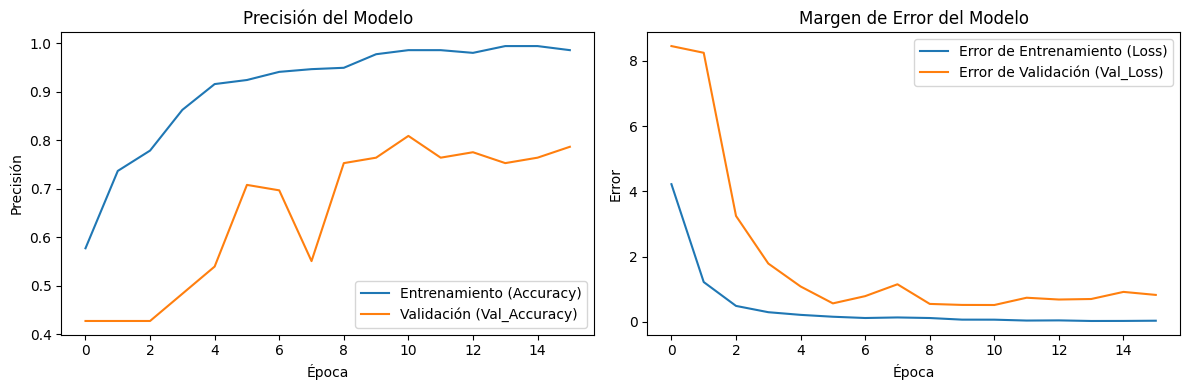

In [7]:
import matplotlib.pyplot as plt

# Crear una figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica 1: Precisión (Accuracy)
ax1.plot(history.history['accuracy'], label='Entrenamiento (Accuracy)')
ax1.plot(history.history['val_accuracy'], label='Validación (Val_Accuracy)')
ax1.set_title('Precisión del Modelo')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend(loc='lower right')

# Gráfica 2: Pérdida/Error (Loss)
ax2.plot(history.history['loss'], label='Error de Entrenamiento (Loss)')
ax2.plot(history.history['val_loss'], label='Error de Validación (Val_Loss)')
ax2.set_title('Margen de Error del Modelo')
ax2.set_xlabel('Época')
ax2.set_ylabel('Error')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Extraer las imágenes y las etiquetas reales del set de validación
test_images = []
true_labels = []

# Recorremos el dataset de validación lote por lote
for images, labels in val_ds:
    test_images.append(images.numpy())
    true_labels.append(labels.numpy())

# Unimos todos los lotes en un solo arreglo gigante
test_images = np.concatenate(test_images, axis=0)
true_labels = np.concatenate(true_labels, axis=0).flatten().astype(int)

# 2. Hacer que el modelo adivine (Predicciones)
print("Generando predicciones.")
predictions = model_custom.predict(test_images)

# Como la salida es una probabilidad (sigmoid), si es > 0.5 lo contamos como clase 1, sino clase 0
predicted_labels = (predictions > 0.5).astype(int).flatten()

# 3. Crear la Matriz de Confusión Matemática
cm = confusion_matrix(true_labels, predicted_labels)

# Definimos los nombres exactos que quieres en tu gráfica
class_names = ["Buenas", "Malas o rotas"] 

# 4. Graficar la Matriz (Estilo Seaborn)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,          # Muestra los números adentro de los cuadros
    fmt='d',             # Formato de número entero (sin decimales)
    cmap='Blues',        # El esquema de color azul idéntico al de tu imagen
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

# 5. Imprimir el reporte detallado (Precision, Recall, F1-Score)
print("\nReporte Detallado de Clasificación:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

ModuleNotFoundError: No module named 'sklearn'